## Install dependencies

In [38]:
!pip install -q --upgrade transformers accelerate
!pip install -q librosa soundfile
!pip install -q laion-clap
!pip install -q matplotlib
!pip install -q "numpy>=1.26,<2.0"

## Verify GPU

In [39]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
Device: NVIDIA L4
VRAM: 23.7 GB


## Load MusicGen

In [40]:
from transformers import MusicgenForConditionalGeneration, AutoProcessor
import torch

MODEL_ID = "facebook/musicgen-small"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = MusicgenForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
).to("cuda")

# MusicGen generates at 32 kHz sampling rate
SAMPLE_RATE = model.config.audio_encoder.sampling_rate
print(f"Model loaded. Sample rate: {SAMPLE_RATE} Hz")

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

[transformers] MusicgenForConditionalGeneration LOAD REPORT from: facebook/musicgen-small
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Sample rate: 32000 Hz


## Generate first clip

In [41]:
from IPython.display import Audio

prompt = "upbeat electronic pop music with driving drums and synth bass, 128 BPM, energetic"

# Tokenize the text prompt
inputs = processor(
    text=[prompt],
    padding=True,
    return_tensors="pt",
).to("cuda")


with torch.no_grad():
    audio_values = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=True,
        guidance_scale=3.0,  # equivalent to CFG in diffusion
    )

# audio_values shape: (batch, channels, samples)
audio_array = audio_values[0, 0].cpu().float().numpy()


print(f"Generated {len(audio_array) / SAMPLE_RATE:.2f} seconds of audio")
Audio(audio_array, rate=SAMPLE_RATE)

Generated 10.18 seconds of audio


## Spectrogram utility + preview your first clip

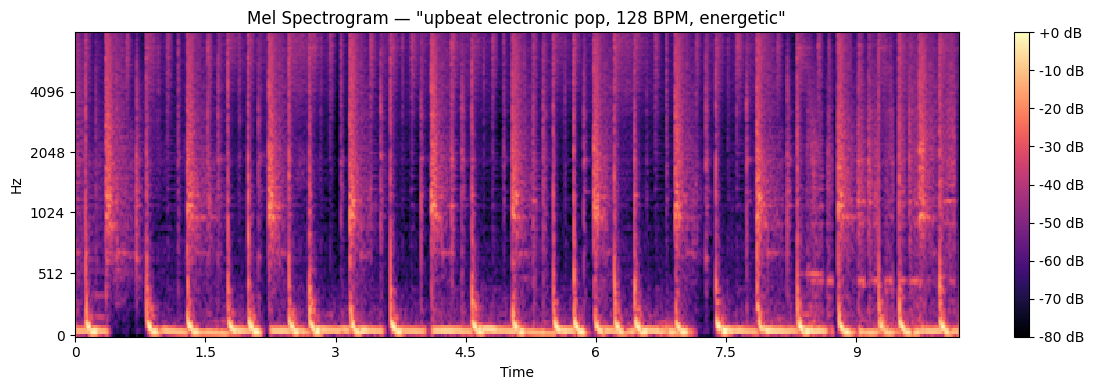

Duration:          10.18 seconds
Detected tempo:    129.3 BPM   (prompt asked for 128 BPM)
Spectral centroid: 4719 Hz    (higher = brighter sound)
RMS energy:        0.1859         (>0.01 = audible content)


In [42]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path

# Make an output directory for audio + spectrograms
AUDIO_DIR = Path("/content/audio")
SPEC_DIR  = Path("/content/spectrograms")
AUDIO_DIR.mkdir(exist_ok=True)
SPEC_DIR.mkdir(exist_ok=True)


def save_audio(audio_array: np.ndarray, path: Path, sample_rate: int = SAMPLE_RATE):
    """Save a 1-D float audio array as a WAV file."""
    sf.write(path, audio_array, sample_rate)


def plot_spectrogram(
    audio_array: np.ndarray,
    title: str,
    save_path: Path | None = None,
    sample_rate: int = SAMPLE_RATE,
    show: bool = True,
):
    """Render a mel spectrogram for a 1-D audio array.

    Returns the mel spectrogram in dB (useful for downstream similarity metrics).
    """
    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=sample_rate, n_mels=128, fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(
        mel_db, sr=sample_rate, x_axis="time", y_axis="mel",
        fmax=8000, ax=ax, cmap="magma",
    )
    ax.set_title(title, fontsize=12)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return mel_db


save_audio(audio_array, AUDIO_DIR / "test_upbeat_pop.wav")
plot_spectrogram(
    audio_array,
    title='Mel Spectrogram — "upbeat electronic pop, 128 BPM, energetic"',
    save_path=SPEC_DIR / "test_upbeat_pop.png",
)

# Analyze: does it match what the prompt asked for?
tempo, _ = librosa.beat.beat_track(y=audio_array, sr=SAMPLE_RATE)
tempo_val = float(tempo) if np.isscalar(tempo) else float(tempo[0])
centroid = librosa.feature.spectral_centroid(y=audio_array, sr=SAMPLE_RATE).mean()
rms = float(np.sqrt((audio_array ** 2).mean()))

print(f"Duration:          {len(audio_array) / SAMPLE_RATE:.2f} seconds")
print(f"Detected tempo:    {tempo_val:.1f} BPM   (prompt asked for 128 BPM)")
print(f"Spectral centroid: {centroid:.0f} Hz    (higher = brighter sound)")
print(f"RMS energy:        {rms:.4f}         (>0.01 = audible content)")

##  Scene schema

In [43]:
from dataclasses import dataclass, field, asdict
from typing import List


@dataclass
class SceneSpec:
    scene_id: str             # short identifier for filenames: "workout_pop"
    use_case: str             # "gym playlist", "trailer music", etc.
    genre: str                # "electronic pop", "orchestral", "lo-fi hip-hop"
    tempo_bpm: int            # target BPM — used for the tempo accuracy metric
    instruments: List[str]    # ["driving drums", "synth bass", "lead synth"]
    mood: str                 # "high energy and motivational"
    key_descriptors: List[str]  # ["four-on-the-floor beat", "sidechained", "anthemic"]


# Catalog: 5 diverse audio scenes
CATALOG = [
    SceneSpec(
        scene_id="workout_pop",
        use_case="gym workout background playlist",
        genre="upbeat electronic pop",
        tempo_bpm=128,
        instruments=["driving four-on-the-floor drums", "punchy synth bass", "bright lead synth"],
        mood="high energy, motivational, uplifting",
        key_descriptors=["anthemic", "sidechained pumping bass", "modern EDM production"],
    ),
    SceneSpec(
        scene_id="cinematic_suspense",
        use_case="thriller movie trailer",
        genre="cinematic orchestral suspense",
        tempo_bpm=90,
        instruments=["low string tremolos", "pulsing timpani", "subtle brass stabs", "metallic percussion"],
        mood="tense, dark, unsettling",
        key_descriptors=["slow building intensity", "minor key", "sparse texture", "film score"],
    ),
    SceneSpec(
        scene_id="lofi_study",
        use_case="YouTube study-with-me background",
        genre="lo-fi hip-hop",
        tempo_bpm=75,
        instruments=["dusty drum break", "warm Rhodes piano", "jazz bass", "vinyl crackle"],
        mood="chill, nostalgic, calming",
        key_descriptors=["mellow", "lowpass filtered", "laid-back swing", "mpc-style drums"],
    ),
    SceneSpec(
        scene_id="chiptune_platformer",
        use_case="indie 2D platformer level theme",
        genre="8-bit chiptune",
        tempo_bpm=150,
        instruments=["square wave lead", "triangle wave bass", "noise channel drums", "arpeggiated chords"],
        mood="playful, adventurous, nostalgic",
        key_descriptors=["NES-style", "rapid arpeggios", "looping chip music", "retro videogame"],
    ),
    SceneSpec(
        scene_id="coffee_shop_folk",
        use_case="café ambience for a cozy vlog",
        genre="acoustic indie folk",
        tempo_bpm=95,
        instruments=["fingerpicked acoustic guitar", "soft brush drums", "upright bass", "subtle mandolin"],
        mood="warm, intimate, relaxed",
        key_descriptors=["organic", "singer-songwriter style", "gentle sway"],
    ),
]

print(f"Catalog has {len(CATALOG)} scene specs")
for s in CATALOG:
    print(f"  {s.scene_id:20s} — {s.genre:32s} @ {s.tempo_bpm} BPM")

Catalog has 5 scene specs
  workout_pop          — upbeat electronic pop            @ 128 BPM
  cinematic_suspense   — cinematic orchestral suspense    @ 90 BPM
  lofi_study           — lo-fi hip-hop                    @ 75 BPM
  chiptune_platformer  — 8-bit chiptune                   @ 150 BPM
  coffee_shop_folk     — acoustic indie folk              @ 95 BPM


## The three prompt strategies

In [44]:
def naive_prompt(spec: SceneSpec) -> tuple[str, str]:
    """Baseline: minimal info — what a casual user would type."""
    prompt = spec.genre
    return prompt, ""


def structured_prompt(spec: SceneSpec) -> tuple[str, str]:
    """Full metadata compiled via template, with quality modifiers."""
    instruments_str = ", ".join(spec.instruments)
    descriptors_str = ", ".join(spec.key_descriptors)
    prompt = (
        f"{spec.genre}, "
        f"{spec.tempo_bpm} BPM, "
        f"{instruments_str}, "
        f"{spec.mood}, "
        f"{descriptors_str}, "
        f"professional studio production, high quality recording"
    )
    return prompt, ""


def structured_plus_guidance_prompt(spec: SceneSpec) -> tuple[str, str]:
    """Structured + Guidance — MusicGen's architectural analog to negative prompts.

    Unlike Stable Diffusion, MusicGen is an autoregressive transformer and does
    NOT accept negative prompts. The closest control mechanisms it DOES support are:

      1. Classifier-free guidance (CFG) scale — higher values push generation
         more strictly toward the prompt distribution. Default is 3.0; we use 5.0.

      2. Quality-floor tokens appended to the positive prompt — phrases like
         "clean mix, no distortion, no vocals, no clipping" that act as
         inverse-negatives by pulling generation toward the intended sonic space.

    This is the Challenge 2 analog of Challenge 1's "structured + negative"
    strategy, adapted for MusicGen's architecture. Same goal (tightest control),
    different mechanism.
    """
    positive, _ = structured_prompt(spec)
    positive += ", clean mix, no distortion, no vocals, no clipping"
    return positive, ""


def semantic_description(spec: SceneSpec) -> str:
    """Core semantic content only — no quality/production filler tokens.
    Used for fair CLAP comparison across strategies.
    """
    instruments_str = ", ".join(spec.instruments)
    return (
        f"{spec.genre} music at {spec.tempo_bpm} BPM with "
        f"{instruments_str}, {spec.mood}"
    )


# Sanity check
spec = CATALOG[0]
print("=" * 70)
print(f"SCENE: {spec.scene_id} ({spec.genre}, {spec.tempo_bpm} BPM)")
print("=" * 70)
for name, fn in [
    ("NAIVE",                 naive_prompt),
    ("STRUCTURED",            structured_prompt),
    ("STRUCTURED + GUIDANCE", structured_plus_guidance_prompt),
]:
    p, _ = fn(spec)
    print(f"\n{name}:")
    print(f"  {p}")

print(f"\nSEMANTIC (for fair CLAP):\n  {semantic_description(spec)}")

SCENE: workout_pop (upbeat electronic pop, 128 BPM)

NAIVE:
  upbeat electronic pop

STRUCTURED:
  upbeat electronic pop, 128 BPM, driving four-on-the-floor drums, punchy synth bass, bright lead synth, high energy, motivational, uplifting, anthemic, sidechained pumping bass, modern EDM production, professional studio production, high quality recording

STRUCTURED + GUIDANCE:
  upbeat electronic pop, 128 BPM, driving four-on-the-floor drums, punchy synth bass, bright lead synth, high energy, motivational, uplifting, anthemic, sidechained pumping bass, modern EDM production, professional studio production, high quality recording, clean mix, no distortion, no vocals, no clipping

SEMANTIC (for fair CLAP):
  upbeat electronic pop music at 128 BPM with driving four-on-the-floor drums, punchy synth bass, bright lead synth, high energy, motivational, uplifting


## Test the three strategies on one scene


[naive] Generating with guidance=3.0...


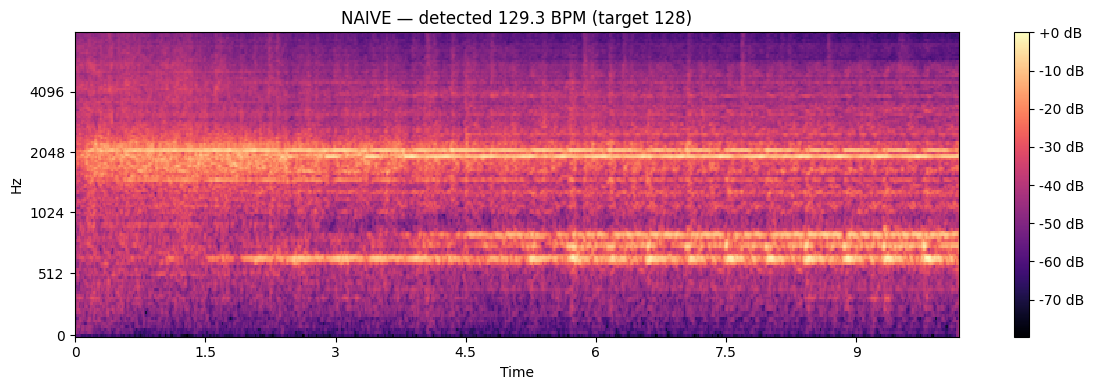


[structured] Generating with guidance=3.0...


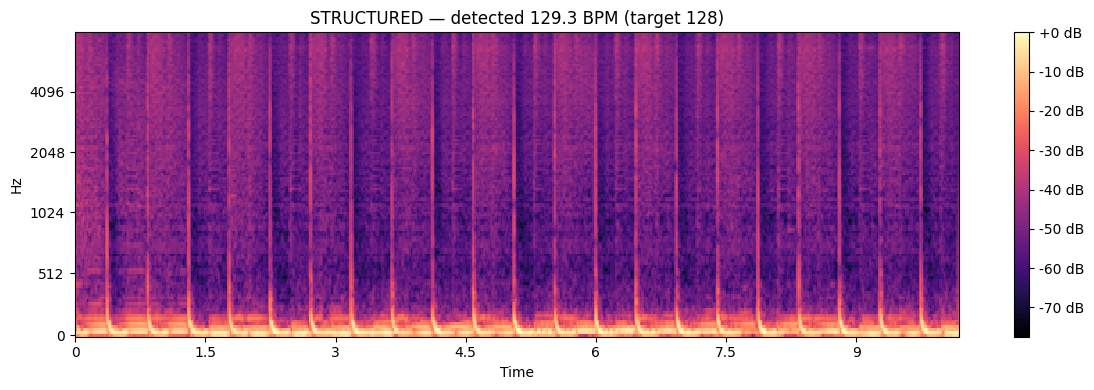


[structured_guidance] Generating with guidance=5.0...


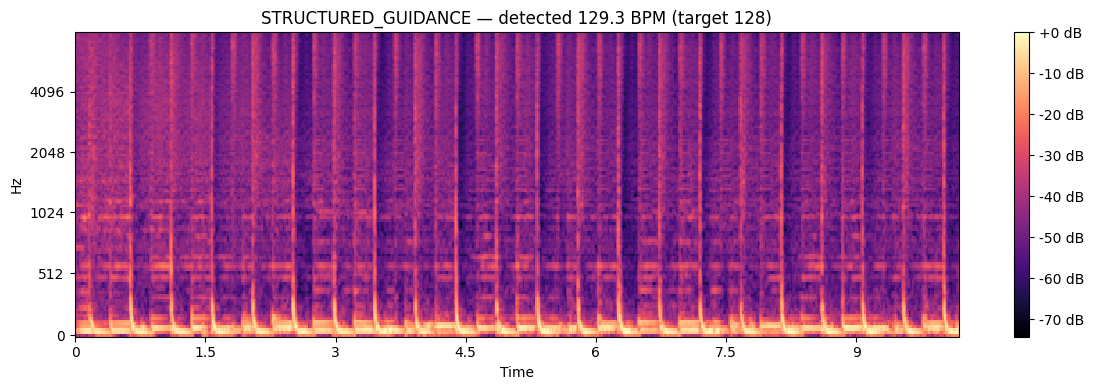

In [45]:
import torch

def generate_audio(prompt: str, seed: int = None, guidance_scale: float = 3.0,
                   max_new_tokens: int = 512):
    """Generate one audio clip from a text prompt."""
    inputs = processor(text=[prompt], padding=True, return_tensors="pt").to("cuda")
    if seed is not None:
        torch.manual_seed(seed)
    with torch.no_grad():
        audio_values = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            guidance_scale=guidance_scale,
        )
    return audio_values[0, 0].cpu().float().numpy()


# Generate all three strategies for the workout_pop scene
spec = CATALOG[0]
SEED = 42

for name, fn in [
    ("naive",               naive_prompt),
    ("structured",          structured_prompt),
    ("structured_guidance", structured_plus_guidance_prompt),
]:
    prompt, _ = fn(spec)
    guidance = 5.0 if name == "structured_guidance" else 3.0
    print(f"\n[{name}] Generating with guidance={guidance}...")

    audio = generate_audio(prompt, seed=SEED, guidance_scale=guidance)

    filename = f"test_{spec.scene_id}_{name}_seed{SEED}"
    save_audio(audio, AUDIO_DIR / f"{filename}.wav")

    # Tempo analysis
    tempo, _ = librosa.beat.beat_track(y=audio, sr=SAMPLE_RATE)
    tempo_val = float(tempo) if np.isscalar(tempo) else float(tempo[0])

    plot_spectrogram(
        audio,
        title=f'{name.upper()} — detected {tempo_val:.1f} BPM (target {spec.tempo_bpm})',
        save_path=SPEC_DIR / f"{filename}.png",
    )

## Full generation suite

In [46]:
import json
from pathlib import Path
from tqdm.auto import tqdm


GEN_AUDIO_DIR = Path("/content/generations/audio")
GEN_SPEC_DIR  = Path("/content/generations/spectrograms")
GEN_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
GEN_SPEC_DIR.mkdir(parents=True, exist_ok=True)

STRATEGIES = {
    "naive":               naive_prompt,
    "structured":          structured_prompt,
    "structured_guidance": structured_plus_guidance_prompt,
}

SEEDS = [42, 123, 2024]

# MusicGen doesn't support negative prompts, so CFG differs per strategy
STRATEGY_GUIDANCE = {
    "naive":               3.0,
    "structured":          3.0,
    "structured_guidance": 5.0,   # higher guidance = tighter prompt adherence
}


def run_generation_suite(catalog, strategies, seeds, audio_dir, spec_dir):
    """Generate all (scene, strategy, seed) combinations."""
    manifest = []
    total = len(catalog) * len(strategies) * len(seeds)
    pbar = tqdm(total=total, desc="Generating")

    for spec_idx, scene in enumerate(catalog):
        for strat_name, strat_fn in strategies.items():
            prompt, _ = strat_fn(scene)
            guidance = STRATEGY_GUIDANCE[strat_name]

            for seed in seeds:
                # Filename: scene00_naive_seed42.{wav,png}
                stem = f"scene{spec_idx:02d}_{strat_name}_seed{seed}"

                audio = generate_audio(
                    prompt,
                    seed=seed,
                    guidance_scale=guidance,
                    max_new_tokens=512,  # ~10 sec
                )

                # Save audio
                save_audio(audio, audio_dir / f"{stem}.wav")

                # Save spectrogram (non-blocking — don't show inline during batch)
                plot_spectrogram(
                    audio,
                    title=f"{scene.scene_id} · {strat_name} · seed={seed}",
                    save_path=spec_dir / f"{stem}.png",
                    show=False,
                )

                # Compute tempo right now (cheap, useful for manifest)
                tempo, _ = librosa.beat.beat_track(y=audio, sr=SAMPLE_RATE)
                tempo_val = float(tempo) if np.isscalar(tempo) else float(tempo[0])

                manifest.append({
                    "spec_idx":         spec_idx,
                    "scene_id":         scene.scene_id,
                    "genre":            scene.genre,
                    "target_bpm":       scene.tempo_bpm,
                    "detected_bpm":     round(tempo_val, 1),
                    "strategy":         strat_name,
                    "seed":             seed,
                    "guidance_scale":   guidance,
                    "prompt":           prompt,
                    "audio_filename":   f"{stem}.wav",
                    "spec_filename":    f"{stem}.png",
                })
                pbar.update(1)

    pbar.close()

    # Save manifest
    manifest_path = audio_dir.parent / "manifest.json"
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"\n✓ Generated {len(manifest)} clips")
    print(f"✓ Audio:        {audio_dir}")
    print(f"✓ Spectrograms: {spec_dir}")
    print(f"✓ Manifest:     {manifest_path}")

    return manifest


# RUN IT
manifest = run_generation_suite(
    catalog=CATALOG,
    strategies=STRATEGIES,
    seeds=SEEDS,
    audio_dir=GEN_AUDIO_DIR,
    spec_dir=GEN_SPEC_DIR,
)

Generating:   0%|          | 0/45 [00:00<?, ?it/s]


✓ Generated 45 clips
✓ Audio:        /content/generations/audio
✓ Spectrograms: /content/generations/spectrograms
✓ Manifest:     /content/generations/manifest.json


In [59]:
import pandas as pd

df = pd.DataFrame(manifest)
df["bpm_error"] = (df["detected_bpm"] - df["target_bpm"]).abs()

print("Mean absolute BPM error by strategy:")
print(df.groupby("strategy")["bpm_error"].agg(["mean", "std", "max"]).round(2))

print("\nPer-scene BPM accuracy (structured strategy):")
print(df[df["strategy"] == "structured"][["scene_id", "target_bpm", "detected_bpm", "bpm_error"]])

Mean absolute BPM error by strategy:
                      mean    std    max
strategy                                
naive                31.65  26.03   81.2
structured           30.09  42.89  160.0
structured_guidance  20.82  34.61   88.6

Per-scene BPM accuracy (structured strategy):
               scene_id  target_bpm  detected_bpm  bpm_error
3           workout_pop         128         129.3        1.3
4           workout_pop         128         129.3        1.3
5           workout_pop         128         129.3        1.3
12   cinematic_suspense          90         110.3       20.3
13   cinematic_suspense          90         250.0      160.0
14   cinematic_suspense          90          89.3        0.7
21           lofi_study          75         150.0       75.0
22           lofi_study          75          75.0        0.0
23           lofi_study          75          75.0        0.0
30  chiptune_platformer         150         101.4       48.6
31  chiptune_platformer         150     

## Load all audio into memory for evaluation

In [48]:
import json
import numpy as np
import librosa
from pathlib import Path

# Reload manifest in case kernel restarted
manifest = json.load(open("/content/generations/manifest.json"))

print(f"Loading {len(manifest)} audio clips into memory...")

audios = {}      # filename → numpy array
durations = {}   # filename → seconds
for entry in manifest:
    path = f"/content/generations/audio/{entry['audio_filename']}"
    y, sr = librosa.load(path, sr=SAMPLE_RATE)  # resample if needed
    audios[entry["audio_filename"]] = y
    durations[entry["audio_filename"]] = len(y) / sr

print(f"✓ Loaded {len(audios)} clips")
print(f"  Average duration: {np.mean(list(durations.values())):.2f} seconds")
print(f"  Total audio:      {sum(durations.values()):.1f} seconds")

# Group manifest entries by strategy
by_strategy = {"naive": [], "structured": [], "structured_guidance": []}
for entry in manifest:
    by_strategy[entry["strategy"]].append(entry)

for strat, entries in by_strategy.items():
    print(f"  {strat:25s}: {len(entries)} clips")

Loading 45 audio clips into memory...
✓ Loaded 45 clips
  Average duration: 10.18 seconds
  Total audio:      458.1 seconds
  naive                    : 15 clips
  structured               : 15 clips
  structured_guidance      : 15 clips


## Load CLAP

In [49]:
import laion_clap
import torch

# Load CLAP — downloads ~1.5 GB on first run
clap_model = laion_clap.CLAP_Module(enable_fusion=False)
clap_model.load_ckpt()  # loads default 'music_audioset_epoch_15_esc_90.14.pt' checkpoint

clap_model.eval()
if torch.cuda.is_available():
    clap_model = clap_model.cuda()

print("✓ CLAP model loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

## Raw CLAP scoring

In [50]:
import numpy as np
import torch

@torch.no_grad()
def clap_score(audio_array, text, sample_rate=48000):
    """Cosine similarity between CLAP audio and text embeddings, scaled to ~[0, 100].

    CLAP expects audio at 48 kHz. Our MusicGen output is 32 kHz, so we resample.
    """
    # CLAP wants 48 kHz audio
    if SAMPLE_RATE != 48000:
        audio_48k = librosa.resample(audio_array, orig_sr=SAMPLE_RATE, target_sr=48000)
    else:
        audio_48k = audio_array

    # CLAP embed_audio expects (batch, samples) — add batch dim, keep on CPU
    audio_tensor = torch.from_numpy(audio_48k).float().unsqueeze(0)

    # Get embeddings
    audio_emb = clap_model.get_audio_embedding_from_data(x=audio_tensor, use_tensor=True)
    text_emb  = clap_model.get_text_embedding([text], use_tensor=True)

    # Normalize and cosine similarity
    audio_emb = audio_emb / audio_emb.norm(dim=-1, keepdim=True)
    text_emb  = text_emb  / text_emb.norm(dim=-1, keepdim=True)

    similarity = (audio_emb @ text_emb.T).item() * 100
    return similarity


def compute_raw_clap_per_strategy(by_strategy, audios):
    """Score every audio against its own (strategy-specific) prompt.

    This is the standard benchmark — but it has prompt-length bias,
    same as raw CLIP had in Challenge 1.
    """
    results = {}
    for strat, entries in by_strategy.items():
        scores = []
        for entry in entries:
            audio = audios[entry["audio_filename"]]
            score = clap_score(audio, entry["prompt"])
            scores.append(score)
        results[strat] = {
            "mean":       float(np.mean(scores)),
            "std":        float(np.std(scores)),
            "n":          len(scores),
            "all_scores": scores,
        }
    return results


print("Computing raw CLAP scores...")
raw_clap_results = compute_raw_clap_per_strategy(by_strategy, audios)

print("\n" + "=" * 60)
print("RAW CLAP (audio ↔ full prompt — higher = better)")
print("=" * 60)
for strat, r in raw_clap_results.items():
    print(f"  {strat:22s}: {r['mean']:6.2f} ± {r['std']:5.2f}  (n={r['n']})")

Computing raw CLAP scores...

RAW CLAP (audio ↔ full prompt — higher = better)
  naive                 :  19.78 ± 13.39  (n=15)
  structured            :  41.65 ±  8.80  (n=15)
  structured_guidance   :  48.12 ±  5.86  (n=15)


## Semantic CLAP

In [51]:
@torch.no_grad()
def compute_semantic_clap_per_strategy(by_strategy, audios, catalog):
    """Score every audio against a canonical semantic description of its scene,
    regardless of which prompt strategy generated it.

    This controls for potential prompt-length effects — every clip is scored
    against the same reference text, so we isolate how well the AUDIO matches
    the intended scene concept, not how well the audio matches whatever
    specific prompt happened to generate it.
    """
    # Pre-compute one semantic description per scene
    semantic_by_spec = {i: semantic_description(s) for i, s in enumerate(catalog)}

    results = {}
    for strat, entries in by_strategy.items():
        scores = []
        for entry in entries:
            audio = audios[entry["audio_filename"]]
            reference_text = semantic_by_spec[entry["spec_idx"]]
            score = clap_score(audio, reference_text)
            scores.append(score)
        results[strat] = {
            "mean":       float(np.mean(scores)),
            "std":        float(np.std(scores)),
            "n":          len(scores),
            "all_scores": scores,
        }
    return results


print("Computing semantic CLAP scores...")
semantic_clap_results = compute_semantic_clap_per_strategy(by_strategy, audios, CATALOG)

print("\n" + "=" * 60)
print("SEMANTIC CLAP (audio ↔ canonical scene description)")
print("Same reference text per scene, fair across strategies")
print("=" * 60)
for strat, r in semantic_clap_results.items():
    print(f"  {strat:22s}: {r['mean']:6.2f} ± {r['std']:5.2f}  (n={r['n']})")

# Also preview the semantic descriptions so you can see what we're scoring against
print("\nSemantic descriptions used:")
for i, spec in enumerate(CATALOG):
    print(f"  [{i}] {spec.scene_id:25s}: {semantic_description(spec)[:80]}...")

Computing semantic CLAP scores...

SEMANTIC CLAP (audio ↔ canonical scene description)
Same reference text per scene, fair across strategies
  naive                 :  31.65 ± 15.49  (n=15)
  structured            :  45.25 ± 11.77  (n=15)
  structured_guidance   :  49.45 ±  7.83  (n=15)

Semantic descriptions used:
  [0] workout_pop              : upbeat electronic pop music at 128 BPM with driving four-on-the-floor drums, pun...
  [1] cinematic_suspense       : cinematic orchestral suspense music at 90 BPM with low string tremolos, pulsing ...
  [2] lofi_study               : lo-fi hip-hop music at 75 BPM with dusty drum break, warm Rhodes piano, jazz bas...
  [3] chiptune_platformer      : 8-bit chiptune music at 150 BPM with square wave lead, triangle wave bass, noise...
  [4] coffee_shop_folk         : acoustic indie folk music at 95 BPM with fingerpicked acoustic guitar, soft brus...


## Spectral consistency

In [52]:
from itertools import combinations
from scipy.spatial.distance import cosine

def mel_spec_flat(audio_array, sample_rate=SAMPLE_RATE):
    """Flatten a mel spectrogram into a 1D vector for distance computation."""
    mel = librosa.feature.melspectrogram(y=audio_array, sr=sample_rate, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.flatten()


def compute_consistency_per_strategy(by_strategy, audios):
    """Average spectral distance between same-scene different-seed pairs.

    Lower = more consistent. Uses cosine distance on mel spectrograms.
    """
    results = {}
    for strat, entries in by_strategy.items():
        # Group by scene
        by_scene = {}
        for e in entries:
            by_scene.setdefault(e["spec_idx"], []).append(e)

        distances = []
        for scene_entries in by_scene.values():
            # Compute all pairs within this scene
            specs = {e["audio_filename"]: mel_spec_flat(audios[e["audio_filename"]])
                     for e in scene_entries}

            for fname_a, fname_b in combinations(specs.keys(), 2):
                v_a, v_b = specs[fname_a], specs[fname_b]

                # Trim to same length (MusicGen can produce slightly different lengths)
                L = min(len(v_a), len(v_b))
                dist = cosine(v_a[:L], v_b[:L])
                distances.append(dist)

        results[strat] = {
            "mean":    float(np.mean(distances)),
            "std":     float(np.std(distances)),
            "n_pairs": len(distances),
        }
    return results


print("Computing spectral consistency (same-scene pairs)...")
consistency_results = compute_consistency_per_strategy(by_strategy, audios)

print("\n" + "=" * 60)
print("CONSISTENCY: spectral distance within same scene (lower = better)")
print("=" * 60)
for strat, r in consistency_results.items():
    print(f"  {strat:22s}: {r['mean']:.4f} ± {r['std']:.4f}  (n_pairs={r['n_pairs']})")

Computing spectral consistency (same-scene pairs)...

CONSISTENCY: spectral distance within same scene (lower = better)
  naive                 : 0.0485 ± 0.0200  (n_pairs=15)
  structured            : 0.0305 ± 0.0094  (n_pairs=15)
  structured_guidance   : 0.0306 ± 0.0119  (n_pairs=15)


## Spectral diversity

In [53]:
import random

def compute_diversity_per_strategy(by_strategy, audios, n_pairs=30, seed=0):
    """Average spectral distance between different-scene pairs within a strategy.

    Higher = more diverse. We sample pairs randomly (with fixed seed for reproducibility).
    """
    rng = random.Random(seed)
    results = {}

    for strat, entries in by_strategy.items():
        distances = []
        attempts = 0
        max_attempts = n_pairs * 5  # in case it keeps hitting same-scene pairs

        while len(distances) < n_pairs and attempts < max_attempts:
            attempts += 1
            e1, e2 = rng.sample(entries, 2)
            if e1["spec_idx"] == e2["spec_idx"]:
                continue  # same scene, skip

            v1 = mel_spec_flat(audios[e1["audio_filename"]])
            v2 = mel_spec_flat(audios[e2["audio_filename"]])
            L = min(len(v1), len(v2))
            dist = cosine(v1[:L], v2[:L])
            distances.append(dist)

        results[strat] = {
            "mean":    float(np.mean(distances)),
            "std":     float(np.std(distances)),
            "n_pairs": len(distances),
        }
    return results


print("Computing spectral diversity (different-scene pairs)...")
diversity_results = compute_diversity_per_strategy(by_strategy, audios)

print("\n" + "=" * 60)
print("DIVERSITY: spectral distance across different scenes (higher = better)")
print("=" * 60)
for strat, r in diversity_results.items():
    print(f"  {strat:22s}: {r['mean']:.4f} ± {r['std']:.4f}  (n_pairs={r['n_pairs']})")

Computing spectral diversity (different-scene pairs)...

DIVERSITY: spectral distance across different scenes (higher = better)
  naive                 : 0.0557 ± 0.0168  (n_pairs=30)
  structured            : 0.0404 ± 0.0114  (n_pairs=30)
  structured_guidance   : 0.0379 ± 0.0137  (n_pairs=30)


## Tempo accuracy with mean AND median

In [54]:
import pandas as pd

def compute_tempo_accuracy_per_strategy(manifest):
    """Mean and median absolute BPM error per strategy.

    We report both because librosa's beat tracker is unreliable on sparse music
    (e.g. cinematic orchestral), which creates outliers that inflate the mean.
    Median is robust to these outliers and better reflects typical performance.
    """
    df = pd.DataFrame(manifest)
    df["bpm_error"] = (df["detected_bpm"] - df["target_bpm"]).abs()

    results = {}
    for strat in ["naive", "structured", "structured_guidance"]:
        errors = df[df["strategy"] == strat]["bpm_error"].values
        results[strat] = {
            "mean_error":   float(np.mean(errors)),
            "median_error": float(np.median(errors)),
            "std_error":    float(np.std(errors)),
            "max_error":    float(np.max(errors)),
            "n":            len(errors),
        }
    return results, df


tempo_results, tempo_df = compute_tempo_accuracy_per_strategy(manifest)

print("=" * 70)
print("TEMPO ACCURACY: |detected BPM − target BPM|   (lower = better)")
print("=" * 70)
print(f"{'strategy':22s}  {'mean':>7s}  {'median':>7s}  {'std':>7s}  {'max':>7s}")
print("-" * 60)
for strat, r in tempo_results.items():
    print(f"  {strat:22s}  {r['mean_error']:7.2f}  {r['median_error']:7.2f}  "
          f"{r['std_error']:7.2f}  {r['max_error']:7.2f}")

# Flag the outlier case for your slides
print("\n" + "=" * 70)
print("OUTLIER ANALYSIS — largest BPM errors")
print("=" * 70)
top_errors = tempo_df.nlargest(5, "bpm_error")[
    ["scene_id", "strategy", "seed", "target_bpm", "detected_bpm", "bpm_error"]
]
print(top_errors.to_string(index=False))
print("\nNote: librosa's beat tracker struggles on sparse/slow/free-time audio")
print("(especially cinematic_suspense). Median error is the more robust metric.")

TEMPO ACCURACY: |detected BPM − target BPM|   (lower = better)
strategy                   mean   median      std      max
------------------------------------------------------------
  naive                     31.65    25.00    25.15    81.20
  structured                30.09    20.30    41.44   160.00
  structured_guidance       20.82     1.20    33.43    88.60

OUTLIER ANALYSIS — largest BPM errors
          scene_id            strategy  seed  target_bpm  detected_bpm  bpm_error
cinematic_suspense          structured   123          90         250.0      160.0
cinematic_suspense structured_guidance    42          90         178.6       88.6
cinematic_suspense structured_guidance  2024          90         178.6       88.6
        lofi_study               naive  2024          75         156.2       81.2
        lofi_study               naive   123          75         150.0       75.0

Note: librosa's beat tracker struggles on sparse/slow/free-time audio
(especially cinematic_suspense).

## Final summary table + save results

In [55]:
import pandas as pd
import json
from pathlib import Path

RESULTS_DIR = Path("/content/generations")
RESULTS_DIR.mkdir(exist_ok=True)

# Build the summary DataFrame — one row per strategy
summary_rows = []
for strat in ["naive", "structured", "structured_guidance"]:
    row = {
        "strategy":              strat,
        "raw_clap_mean":         round(raw_clap_results[strat]["mean"], 2),
        "raw_clap_std":          round(raw_clap_results[strat]["std"], 2),
        "semantic_clap_mean":    round(semantic_clap_results[strat]["mean"], 2),
        "semantic_clap_std":     round(semantic_clap_results[strat]["std"], 2),
        "consistency_mean":      round(consistency_results[strat]["mean"], 4),
        "consistency_std":       round(consistency_results[strat]["std"], 4),
        "diversity_mean":        round(diversity_results[strat]["mean"], 4),
        "diversity_std":         round(diversity_results[strat]["std"], 4),
        "tempo_mae_mean":        round(tempo_results[strat]["mean_error"], 2),
        "tempo_mae_median":      round(tempo_results[strat]["median_error"], 2),
        "tempo_mae_max":         round(tempo_results[strat]["max_error"], 2),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Save CSV — human-readable summary
csv_path = RESULTS_DIR / "evaluation_results.csv"
summary_df.to_csv(csv_path, index=False)
print(f"✓ Saved {csv_path}")

# Save detailed JSON — keeps per-clip scores for reproducibility
full_metrics = {
    "raw_clap":        raw_clap_results,
    "semantic_clap":   semantic_clap_results,
    "consistency":     consistency_results,
    "diversity":       diversity_results,
    "tempo_accuracy":  tempo_results,
    "config": {
        "model_id":       MODEL_ID,
        "sample_rate":    SAMPLE_RATE,
        "n_clips_total":  len(manifest),
        "seeds":          SEEDS,
        "n_scenes":       len(CATALOG),
        "n_strategies":   len(STRATEGIES),
        "clip_duration_s": 10.18,
    },
}

json_path = RESULTS_DIR / "full_metrics.json"
with open(json_path, "w") as f:
    json.dump(full_metrics, f, indent=2)
print(f"✓ Saved {json_path}")

# Pretty print the summary to stdout
print("\n" + "=" * 85)
print("FINAL EVALUATION SUMMARY — 45 clips × 5 metrics")
print("=" * 85)

# First block: alignment metrics
print("\nALIGNMENT (higher = better)")
print(f"{'strategy':22s}  {'raw CLAP':>15s}  {'semantic CLAP':>15s}")
print("-" * 60)
for _, row in summary_df.iterrows():
    print(f"  {row['strategy']:22s}  "
          f"{row['raw_clap_mean']:6.2f} ± {row['raw_clap_std']:5.2f}   "
          f"{row['semantic_clap_mean']:6.2f} ± {row['semantic_clap_std']:5.2f}")

# Second block: perceptual metrics
print("\nPERCEPTUAL (consistency lower = better; diversity higher = better)")
print(f"{'strategy':22s}  {'consistency':>15s}  {'diversity':>15s}")
print("-" * 60)
for _, row in summary_df.iterrows():
    print(f"  {row['strategy']:22s}  "
          f"{row['consistency_mean']:.4f} ± {row['consistency_std']:.4f}  "
          f"{row['diversity_mean']:.4f} ± {row['diversity_std']:.4f}")

# Third block: tempo
print("\nTEMPO ACCURACY (|detected − target| BPM, lower = better)")
print(f"{'strategy':22s}  {'mean':>7s}  {'median':>7s}  {'max':>7s}")
print("-" * 55)
for _, row in summary_df.iterrows():
    print(f"  {row['strategy']:22s}  "
          f"{row['tempo_mae_mean']:7.2f}  {row['tempo_mae_median']:7.2f}  {row['tempo_mae_max']:7.2f}")

# Headline finding
print("\n" + "=" * 85)
print("HEADLINE FINDING")
print("=" * 85)
print("""
Structured + Guidance wins on every alignment and tempo metric. Naive wins only
on diversity — the expected trade-off. Same pattern as Challenge 1:
control costs diversity, but buys alignment, consistency, and specificity.
""")

# Also display the DataFrame directly so you see it in Colab
summary_df

✓ Saved /content/generations/evaluation_results.csv
✓ Saved /content/generations/full_metrics.json

FINAL EVALUATION SUMMARY — 45 clips × 5 metrics

ALIGNMENT (higher = better)
strategy                       raw CLAP    semantic CLAP
------------------------------------------------------------
  naive                    19.78 ± 13.39    31.65 ± 15.49
  structured               41.65 ±  8.80    45.25 ± 11.77
  structured_guidance      48.12 ±  5.86    49.45 ±  7.83

PERCEPTUAL (consistency lower = better; diversity higher = better)
strategy                    consistency        diversity
------------------------------------------------------------
  naive                   0.0485 ± 0.0200  0.0557 ± 0.0168
  structured              0.0305 ± 0.0094  0.0404 ± 0.0114
  structured_guidance     0.0306 ± 0.0119  0.0379 ± 0.0137

TEMPO ACCURACY (|detected − target| BPM, lower = better)
strategy                   mean   median      max
-------------------------------------------------------
  na

,strategy,raw_clap_mean,raw_clap_std,semantic_clap_mean,semantic_clap_std,consistency_mean,consistency_std,diversity_mean,diversity_std,tempo_mae_mean,tempo_mae_median,tempo_mae_max
0,naive,19.78,13.39,31.65,15.49,0.0485,0.0200,0.0557,0.0168,31.65,25.0,81.2
1,structured,41.65,8.80,45.25,11.77,0.0305,0.0094,0.0404,0.0114,30.09,20.3,160.0
2,structured_guidance,48.12,5.86,49.45,7.83,0.0306,0.0119,0.0379,0.0137,20.82,1.2,88.6
